Final modelling dataset shape:
(499, 6)

Missing values:
country                 0
year                    0
ev_stock_lag1           0
ev_stock_share_lag1     0
charging_points_lag1    0
ev_sales_share          0
dtype: int64

Years available:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Training dataset shape:
(421, 6)

Testing dataset shape:
(78, 6)

Training years:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Testing years:
[np.int64(2023), np.int64(2024)]

X_train shape:
(421, 3)

X_test shape:
(78, 3)

Final Model Performance Comparison:
               Model        R2       MAE       RMSE
0      Tuned XGBoost  0.749130  7.456753  10.321213
1      Random For

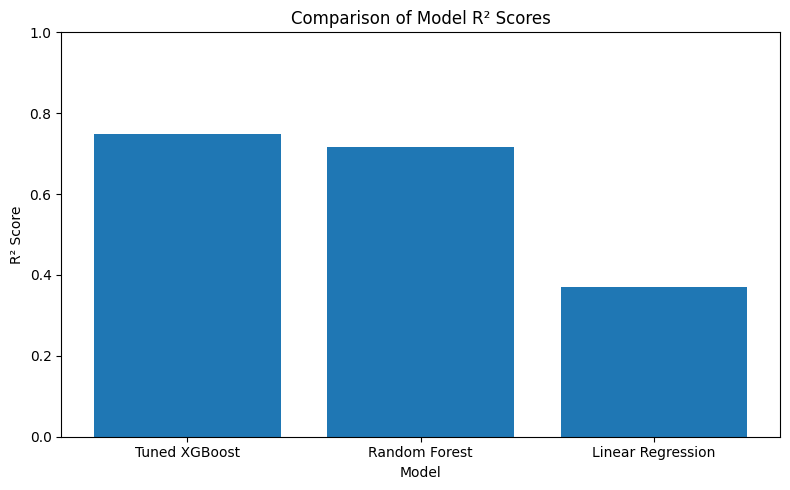

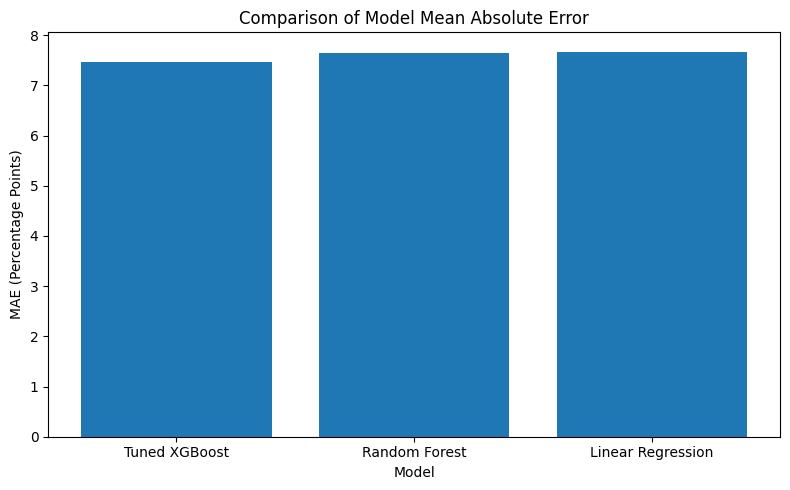

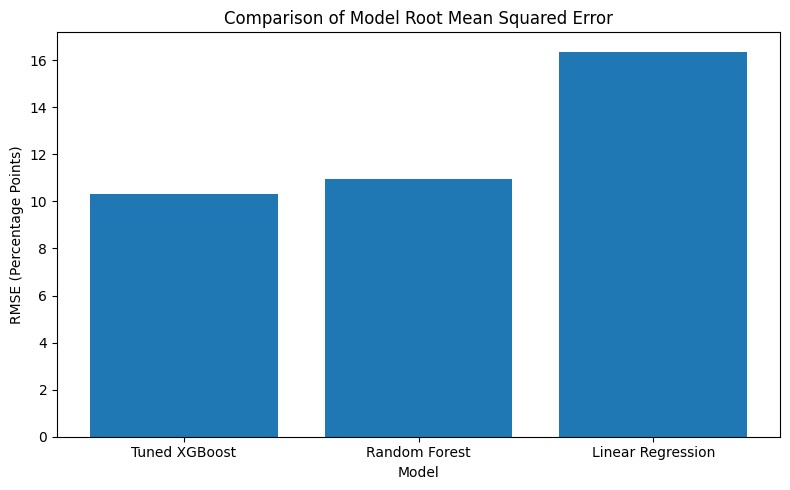


Prediction Comparison:
        country  year  actual_ev_sales_share  linear_regression_prediction  \
421   Australia  2023                  12.00                      5.232853   
422     Austria  2023                  27.00                     19.747505   
423     Belgium  2023                  41.00                     28.831002   
424      Brazil  2023                   3.00                      2.384412   
425      Canada  2023                  13.00                     12.095732   
426       Chile  2023                   0.75                      2.049280   
427       China  2023                  38.00                     41.648583   
428    Colombia  2023                   3.90                      3.385916   
429  Costa Rica  2023                  13.00                      4.523871   
430     Denmark  2023                  46.00                     48.591378   

     random_forest_prediction  xgboost_prediction  
421                    5.6470            6.193113  
422          

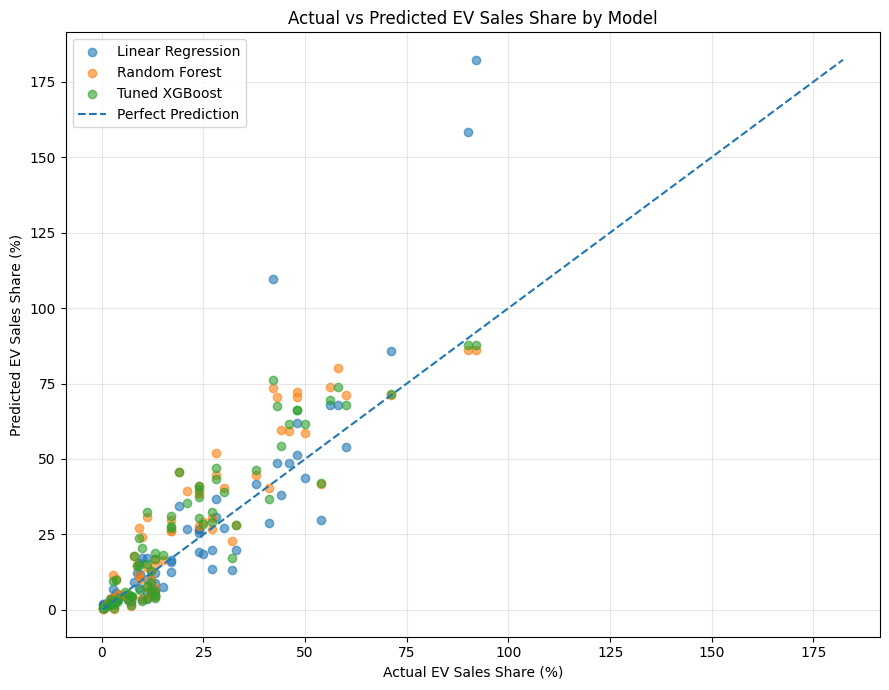


Largest Tuned XGBoost Prediction Errors:
            country  year  actual_ev_sales_share  xgboost_prediction  \
474         Iceland  2024                   42.0           76.055984   
472         Germany  2024                   19.0           45.816986   
462         Belgium  2024                   43.0           67.704239   
484     New Zealand  2024                   11.0           32.505257   
497  United Kingdom  2024                   28.0           47.010021   
466           China  2024                   48.0           66.322121   
483     Netherlands  2024                   48.0           66.203506   
471          France  2024                   24.0           41.106289   
433         Germany  2023                   24.0           40.214577   
492          Sweden  2024                   58.0           74.009087   

     xgb_absolute_error  
474           34.055984  
472           26.816986  
462           24.704239  
484           21.505257  
497           19.010021  
466      

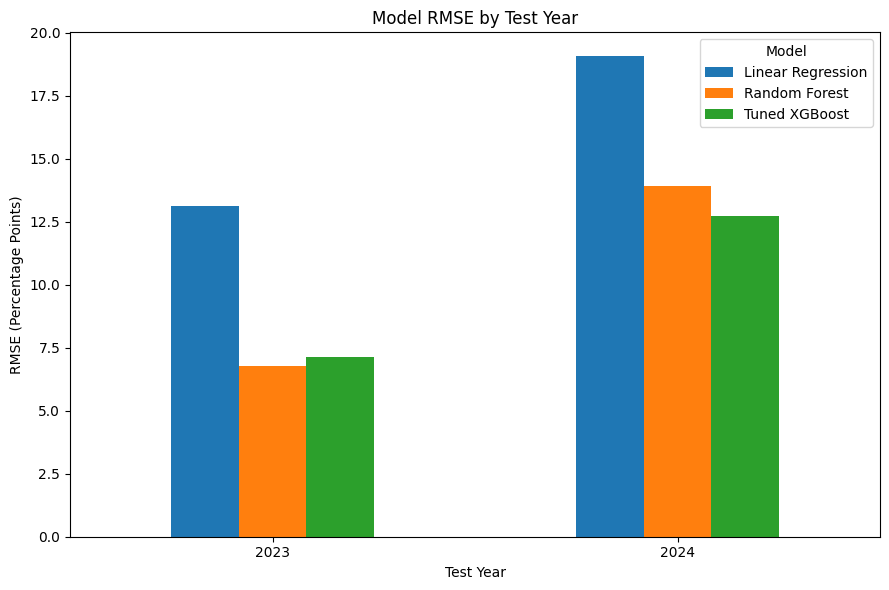


Mean Prediction Error:
               Model  Mean_Error
0  Linear Regression   -1.976445
1      Random Forest   -4.937796
2      Tuned XGBoost   -4.481612

Final Selected Predictive Model:
Tuned XGBoost

Final Selected Model Performance:
R²   : 0.7491
MAE  : 7.4568
RMSE : 10.3212


In [1]:
# ============================================================
# FINAL MODEL COMPARISON
# Linear Regression vs Random Forest vs XGBoost
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from xgboost import XGBRegressor


file_path = "../data/processed/feature_engineered_ev_dataset.csv"

master_df = pd.read_csv(file_path)


# ============================================================
# 2. DEFINE FEATURES AND TARGET
# ============================================================

features = [
    "ev_stock_lag1",
    "ev_stock_share_lag1",
    "charging_points_lag1"
]

target = "ev_sales_share"


# ============================================================
# 3. CREATE FINAL MODELLING DATAFRAME
# ============================================================

comparison_df = master_df[
    [
        "country",
        "year",
        "ev_stock_lag1",
        "ev_stock_share_lag1",
        "charging_points_lag1",
        "ev_sales_share"
    ]
].dropna().copy()


comparison_df = (
    comparison_df
    .sort_values(["year", "country"])
    .reset_index(drop=True)
)


print("Final modelling dataset shape:")
print(comparison_df.shape)


print("\nMissing values:")
print(comparison_df.isnull().sum())


print("\nYears available:")
print(
    sorted(
        comparison_df["year"].unique()
    )
)


# ============================================================
# 4. CREATE TIME-BASED TRAIN / TEST SPLIT
# ============================================================

train_df = comparison_df[
    comparison_df["year"] <= 2022
].copy()


test_df = comparison_df[
    comparison_df["year"].isin([2023, 2024])
].copy()


print("\nTraining dataset shape:")
print(train_df.shape)


print("\nTesting dataset shape:")
print(test_df.shape)


print("\nTraining years:")
print(
    sorted(
        train_df["year"].unique()
    )
)


print("\nTesting years:")
print(
    sorted(
        test_df["year"].unique()
    )
)


# ============================================================
# 5. CREATE TRAINING AND TEST VARIABLES
# ============================================================

X_train = train_df[features]

y_train = train_df[target]


X_test = test_df[features]

y_test = test_df[target]


print("\nX_train shape:")
print(X_train.shape)


print("\nX_test shape:")
print(X_test.shape)


# ============================================================
# 6. CREATE FINAL LINEAR REGRESSION MODEL
# ============================================================

linear_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ]
)


# ============================================================
# 7. CREATE FINAL RANDOM FOREST MODEL
# ============================================================

random_forest_model = RandomForestRegressor(
    random_state=42
)


# ============================================================
# 8. CREATE FINAL TUNED XGBOOST MODEL
# ============================================================


xgboost_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)


# ============================================================
# 9. TRAIN FINAL MODELS
# ============================================================

linear_model.fit(
    X_train,
    y_train
)


random_forest_model.fit(
    X_train,
    y_train
)


xgboost_model.fit(
    X_train,
    y_train
)


# ============================================================
# 10. GENERATE FINAL TEST PREDICTIONS
# ============================================================

y_pred_linear = linear_model.predict(
    X_test
)


y_pred_rf = random_forest_model.predict(
    X_test
)


y_pred_xgb = xgboost_model.predict(
    X_test
)


# ============================================================
# 11. CREATE MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model_name,
    y_actual,
    y_predicted
):
    """
    Calculate R², MAE and RMSE for a regression model.
    """

    r2 = r2_score(
        y_actual,
        y_predicted
    )


    mae = mean_absolute_error(
        y_actual,
        y_predicted
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_actual,
            y_predicted
        )
    )


    return {
        "Model": model_name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }


# ============================================================
# 12. EVALUATE ALL FINAL MODELS
# ============================================================

model_results = []


model_results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        y_pred_linear
    )
)


model_results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)


model_results.append(
    evaluate_model(
        "Tuned XGBoost",
        y_test,
        y_pred_xgb
    )
)


# ============================================================
# 13. CREATE FINAL MODEL COMPARISON DATAFRAME
# ============================================================

model_comparison_df = pd.DataFrame(
    model_results
)


model_comparison_df = (
    model_comparison_df
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)


print(
    "\nFinal Model Performance Comparison:"
)


print(
    model_comparison_df
)


# ============================================================
# 14. CREATE MODEL RANKING
# ============================================================

model_comparison_df[
    "RMSE_Rank"
] = (

    model_comparison_df[
        "RMSE"
    ]

    .rank(
        ascending=True,
        method="min"
    )

    .astype(int)

)


print(
    "\nFinal Model Ranking:"
)


print(
    model_comparison_df
)


# ============================================================
# 15. R² COMPARISON PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    model_comparison_df["Model"],
    model_comparison_df["R2"]
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "R² Score"
)


plt.title(
    "Comparison of Model R² Scores"
)


plt.ylim(
    0,
    1
)


plt.tight_layout()


plt.show()


# ============================================================
# 16. MAE COMPARISON PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    model_comparison_df["Model"],
    model_comparison_df["MAE"]
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "MAE (Percentage Points)"
)


plt.title(
    "Comparison of Model Mean Absolute Error"
)


plt.tight_layout()


plt.show()


# ============================================================
# 17. RMSE COMPARISON PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    model_comparison_df["Model"],
    model_comparison_df["RMSE"]
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "RMSE (Percentage Points)"
)


plt.title(
    "Comparison of Model Root Mean Squared Error"
)


plt.tight_layout()


plt.show()


# ============================================================
# 18. CREATE FINAL PREDICTION COMPARISON DATAFRAME
# ============================================================

prediction_comparison_df = test_df[
    [
        "country",
        "year"
    ]
].copy()


prediction_comparison_df[
    "actual_ev_sales_share"
] = y_test.values


prediction_comparison_df[
    "linear_regression_prediction"
] = y_pred_linear


prediction_comparison_df[
    "random_forest_prediction"
] = y_pred_rf


prediction_comparison_df[
    "xgboost_prediction"
] = y_pred_xgb


print(
    "\nPrediction Comparison:"
)


print(
    prediction_comparison_df.head(10)
)


# ============================================================
# 19. ACTUAL VS PREDICTED PLOT FOR ALL MODELS
# ============================================================

plt.figure(
    figsize=(9, 7)
)


plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.6,
    label="Linear Regression"
)


plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6,
    label="Random Forest"
)


plt.scatter(
    y_test,
    y_pred_xgb,
    alpha=0.6,
    label="Tuned XGBoost"
)


minimum_value = min(
    y_test.min(),
    y_pred_linear.min(),
    y_pred_rf.min(),
    y_pred_xgb.min()
)


maximum_value = max(
    y_test.max(),
    y_pred_linear.max(),
    y_pred_rf.max(),
    y_pred_xgb.max()
)


plt.plot(
    [
        minimum_value,
        maximum_value
    ],
    [
        minimum_value,
        maximum_value
    ],
    linestyle="--",
    label="Perfect Prediction"
)


plt.xlabel(
    "Actual EV Sales Share (%)"
)


plt.ylabel(
    "Predicted EV Sales Share (%)"
)


plt.title(
    "Actual vs Predicted EV Sales Share by Model"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ============================================================
# 20. CALCULATE ABSOLUTE PREDICTION ERRORS
# ============================================================

prediction_comparison_df[
    "linear_absolute_error"
] = (

    prediction_comparison_df[
        "actual_ev_sales_share"
    ]

    -

    prediction_comparison_df[
        "linear_regression_prediction"
    ]

).abs()


prediction_comparison_df[
    "rf_absolute_error"
] = (

    prediction_comparison_df[
        "actual_ev_sales_share"
    ]

    -

    prediction_comparison_df[
        "random_forest_prediction"
    ]

).abs()


prediction_comparison_df[
    "xgb_absolute_error"
] = (

    prediction_comparison_df[
        "actual_ev_sales_share"
    ]

    -

    prediction_comparison_df[
        "xgboost_prediction"
    ]

).abs()


# ============================================================
# 21. DISPLAY LARGEST XGBOOST ERRORS
# ============================================================

print(
    "\nLargest Tuned XGBoost Prediction Errors:"
)


print(

    prediction_comparison_df

    .sort_values(
        "xgb_absolute_error",
        ascending=False
    )

    [
        [
            "country",
            "year",
            "actual_ev_sales_share",
            "xgboost_prediction",
            "xgb_absolute_error"
        ]
    ]

    .head(10)

)


# ============================================================
# 22. CALCULATE PERFORMANCE BY TEST YEAR
# ============================================================

yearly_model_results = []


model_predictions = {

    "Linear Regression":
        "linear_regression_prediction",

    "Random Forest":
        "random_forest_prediction",

    "Tuned XGBoost":
        "xgboost_prediction"

}


for year in sorted(
    prediction_comparison_df[
        "year"
    ].unique()
):


    year_df = prediction_comparison_df[

        prediction_comparison_df[
            "year"
        ] == year

    ]


    for (
        model_name,
        prediction_column
    ) in model_predictions.items():


        year_actual = year_df[
            "actual_ev_sales_share"
        ]


        year_predicted = year_df[
            prediction_column
        ]


        yearly_model_results.append({

            "Year": year,

            "Model": model_name,

            "R2": r2_score(
                year_actual,
                year_predicted
            ),

            "MAE": mean_absolute_error(
                year_actual,
                year_predicted
            ),

            "RMSE": np.sqrt(
                mean_squared_error(
                    year_actual,
                    year_predicted
                )
            )

        })


yearly_model_comparison_df = pd.DataFrame(
    yearly_model_results
)


print(
    "\nModel Performance by Test Year:"
)


print(
    yearly_model_comparison_df
)


# ============================================================
# 23. RMSE BY TEST YEAR PLOT
# ============================================================

yearly_rmse_pivot = (

    yearly_model_comparison_df

    .pivot(
        index="Year",
        columns="Model",
        values="RMSE"
    )

)


yearly_rmse_pivot.plot(
    kind="bar",
    figsize=(9, 6)
)


plt.xlabel(
    "Test Year"
)


plt.ylabel(
    "RMSE (Percentage Points)"
)


plt.title(
    "Model RMSE by Test Year"
)


plt.xticks(
    rotation=0
)


plt.legend(
    title="Model"
)


plt.tight_layout()


plt.show()


# ============================================================
# 24. CALCULATE MEAN PREDICTION BIAS
# ============================================================

prediction_bias_results = []


for (
    model_name,
    prediction_column
) in model_predictions.items():


    mean_error = (

        prediction_comparison_df[
            "actual_ev_sales_share"
        ]

        -

        prediction_comparison_df[
            prediction_column
        ]

    ).mean()


    prediction_bias_results.append({

        "Model": model_name,

        "Mean_Error": mean_error

    })


prediction_bias_df = pd.DataFrame(
    prediction_bias_results
)


print(
    "\nMean Prediction Error:"
)


print(
    prediction_bias_df
)


# ============================================================
# 25. DISPLAY FINAL BEST MODEL
# ============================================================

best_model = model_comparison_df.iloc[0]


print(
    "\nFinal Selected Predictive Model:"
)


print(
    best_model["Model"]
)


print(
    "\nFinal Selected Model Performance:"
)


print(
    f"R²   : {best_model['R2']:.4f}"
)


print(
    f"MAE  : {best_model['MAE']:.4f}"
)


print(
    f"RMSE : {best_model['RMSE']:.4f}"
)